In [83]:
import duckdb
import pandas as pd
from pathlib import Path
import diskcache
from itertools import chain
from collections import Counter

import igraph as ig
import matplotlib.pyplot as plt
import seaborn.objects as so
import seaborn as sns

from utils.pandas_setup import pandas_setup
pandas_setup()

import pyalex
from pyalex import Works, Authors, Sources, Institutions, Topics, Publishers, Funders
pyalex.config.email = "Lawrence.Cram@anu.edu.au"
pyalex.config.max_retries = 0
pyalex.config.retry_backoff_factor = 0.1
pyalex.config.retry_http_codes = [429, 500, 503]

MY_DATA_PATH = Path('../DATA/')
MY_DATABASE_FILE = Path(MY_DATA_PATH / 'econ.duckdb')
MY_CACHE_FILE = Path('/home/lc/m/.cache/econommicsbusiness/cache.db')
DATAFILES_PATH = Path('../DATAFILES')

In [84]:
class SetUp:

    def __init__(self):
        self._setup_db()
        self._setup_cache()
        return
    
    def _setup_db(self):
        self.db = duckdb.connect(MY_DATABASE_FILE)
        self.db.sql("ATTACH IF NOT EXISTS ':memory:'")
        self.db.sql(""" SET memory_limit = '56GB';
                        SET threads = 6;
                        SET preserve_insertion_order = false;
                        SET order_by_non_integer_literal=true;
                        SET enable_progress_bar = true;
                        SET temp_directory = '/home/lc/m/.tmp';
                    """)
        self.db.sql("SHOW ALL TABLES").show()
        return
    
    def _setup_cache(self):
        self.cache = diskcache.Cache(MY_CACHE_FILE, size_limit=16_000_000_000)
        print(f'{self.cache.check() = }')
        print(f'{self.cache.volume() = }')
        return
    
    def name_of_global_obj(self, obj=None):
        for objname, oid in globals().items():
            if oid is obj:
                return objname
            

In [85]:
class CoauthorshipNetwork(SetUp):

    def __init__(self):
        super().__init__()
        return
    
    def build_authorship_network(self):
        # get works from a few small, top  journals
        source_list = 'https://openalex.org/S2764736659 https://openalex.org/S7397502'
        sql = f"""
                CREATE OR REPLACE TABLE memory.network AS 
                    SELECT replace(source_id, 'https://openalex.org/', '') AS source_id,
                            -- any_value(source_name),
                            replace(institution_id, 'https://openalex.org/', '') AS institution_id,
                            -- any_value(institution_name)
                            count(work_id) AS weight,
                        FROM works w
                        LEFT JOIN authorships a
                            USING (work_id) 
                            WHERE contains('{source_list}', w.source_id) = true 
                                    AND author_name NOT NULL
                                    AND work_id NOT NULL
                        GROUP BY source_id, institution_id, source_name, institution_name
                        ORDER BY weight DESC, source_name, institution_name
            """
        self.db.sql(sql)
        self.db.sql("SELECT * FROM memory.network").show()
        self.db.sql("COPY memory.network TO '../DATA/NETWORK_DATA/trial.csv' (HEADER false, DELIMITER '\t')")
        return
    
    def extract_graph(self):
        self.g = ig.Graph.Read_Ncol('../DATA/NETWORK_DATA/trial.csv', names=True)
        print(self.g.get_edgelist())
        print(self.g.es["weight"])
        print(self.g.vs["name"])
        return
    
    def pagerank(self):
        ranks = self.g.pagerank()
        print(ranks)
        return


In [86]:
class CitationNetwork(SetUp):

    def __init__(self, kind=None):
        super().__init__()
        self.kind = kind
        return

    def build_base(self):
        sql = """
                CREATE OR REPLACE TABLE memory.base AS
                    SELECT DISTINCT w.work_id,
                            w.source_id,
                            w.source_name,
                            w.host_name,
                            w.publication_year,
                            a.author_id,
                            a.author_name,
                            a.institution_id,
                            a.institution_name,
                            a.country_code
                        FROM works w
                            LEFT JOIN authorships a
                                USiNG (work_id)
                        WHERE contains('article review preprint letter', w.type) = true 
                                AND publication_year >= 2010
                    ORDER BY work_id
            """
        self.db.sql(sql)
        self._build_name_dictionaries()
        return
    
    def _build_name_dictionaries(self):
        df = self.db.sql("SELECT * FROM memory.base").df()
        self.name = {**dict(zip(df.source_id, df.source_name)), **dict(zip(df.institution_id, df.institution_name))}
        self.name_ext = {**dict(zip(df.source_id, df.host_name)), **dict(zip(df.institution_id, df.country_code))}
        return
    
    def report_base(self):
        df = self.db.sql("SELECT * FROM memory.base").df()
        print(f'{df.shape = }\n{df.head()}')
        print(f'{df.work_id.nunique() = }')
        print(f'{df.source_id.nunique() = }')
        print(f'{df.author_id.nunique() = }')
        print(f'{df.institution_id.nunique() = }')
        print(f'{df.country_code.nunique() = }')                        
        return

    def build_citation_tables(self):
        # build table of citation counts between citer and cited (journals and institutions)
        for citer_kind, cited_kind in [('source', 'source'), ('source', 'institution'), ('institution', 'source'), ('institution', 'institution')]:
            print(f'{citer_kind = } {cited_kind = }')
            sql = f"""
                    CREATE OR REPlACE TABLE memory.citation_network AS
                        SELECT c.{citer_kind}_id AS citer,
                                b2.{cited_kind}_id AS cited,
                                count(c.citer_id) AS weights -- count the number of citing works
                            FROM
                            -- SET UP THE "citer" PART
                            (
                            SELECT c.work_id AS citer_id,
                                    unnest(referenced_works) AS cited_id,
                                    b1.{citer_kind}_id,
                                    b1.{citer_kind}_name,
                                FROM cited c
                                LEFT JOIN memory.base b1
                                    USING (work_id)
                            ) c
                            -- SET UP THE "citer" PART
                                LEFT JOIN memory.base b2
                                    ON c.cited_id = b2.work_id
                            WHERE c.{citer_kind}_id NOT NULL 
                                    AND b2.{cited_kind}_id NOT NULL
                        GROUP BY ALL 
                """
            self.db.sql(sql)
            self.db.sql(f"COPY memory.citation_network TO '../DATA/NETWORK_DATA/citation_network_{citer_kind}_{cited_kind}.csv' (HEADER true, DELIMITER ',')")
        return        

    def report_citations(self):
        for citer_kind, cited_kind in [('source', 'source'), ('source', 'institution'), ('institution', 'source'), ('institution', 'institution')]:
            print(f'{citer_kind = } {cited_kind = }')
            df = pd.read_csv(f'../DATA/NETWORK_DATA/citation_network_{citer_kind}_{cited_kind}.csv')
            print(f'DISTINCT CITERS {df.citer.nunique() = }')
            print(f'DISTINCT CITEDS {df.cited.nunique() = }')
            cntr = Counter(df.weights)
            print(f'COUNT DISTRIBTION {cntr.most_common(8) = }')
            print(f'COUNT DISTRIBTION {cntr.most_common()[:-8:-1] = }')
            print(f'TOTAL CITATIONS {cntr.total() = }')
        return
    
    def extract_citation_tables(self):
        for citer_kind, cited_kind in [('source', 'source'), ('source', 'institution'), ('institution', 'source'), ('institution', 'institution'),]:
                                        # ('both', 'source'), ('both', 'institution'), 
                                        # ('source', 'both'), ('institution', 'both'),
                                        # ('both', 'both)')]:
            print(f'{citer_kind = } {cited_kind = }')
            # if 'both' not in [citer_kind, cited_kind]?
            self.extract_graph(citer_kind, cited_kind)
            self.run_pagerank(citer_kind, cited_kind)
            self.report_pagerank(citer_kind,cited_kind)
            self.weighted_citation_count(citer_kind, cited_kind)
            self.plot_model(citer_kind, cited_kind)
        return

    def extract_graph(self, citer_kind, cited_kind):
        df_edges = pd.read_csv(f'../DATA/NETWORK_DATA/citation_network_{citer_kind}_{cited_kind}.csv')
        df_edges = df_edges[df_edges.weights >= 50]
        print(f'*** DROP EDGES WITH FEWER THAN 50 CITATIONS {df_edges.shape = }\n{df_edges.head()}')
        self.g = ig.Graph.DataFrame(df_edges, directed=True, use_vids=False)
        print(self.g.get_edgelist())
        summary = ig.summary(self.g, verbosity=0, width=78, edge_list_format='auto', max_rows=99999, print_graph_attributes=False, 
                                          print_vertex_attributes=False, print_edge_attributes=False, full=False)
        print(f'*** SUMMARY OF self.g\n{summary}')
        return
    
    def run_pagerank(self, citer_kind, cited_kind):
        print('pageRank')
        ranks = self.g.pagerank(weights='weights', implementation='power')
        print(f'>> CHECK pageRank  - should sum to unity {sum(ranks) = }')
        rank_max = max(ranks)
        ranks = [r/rank_max for r in ranks]
        self.pagerank = pd.DataFrame(zip(ranks, self.g.vs["name"], self.g.degree()), columns=['pageRank','citer', 'pub_count']).sort_values('pageRank', ascending=False)
        temp = self.pagerank
        self.db.sql(f"CREATE OR REPLACE TABLE econ.pagerank_{citer_kind}_{cited_kind} AS SELECT * FROM temp")
        return
    
    def report_pagerank(self, citer_kind, cited_kind):        
        self.pagerank['name'] = [self.name.get(id) for id in self.pagerank['citer']]
        self.pagerank['name_ext'] = [self.name_ext.get(id) for id in self.pagerank['citer']]
        self.db.sql(f"SELECT * FROM econ.pagerank_{citer_kind}_{cited_kind}").show()
        print(f'{self.pagerank.shape = }\n{self.pagerank.head(8)}')
        print(f'\n{self.pagerank.tail(8)}')
        print(f'Sum of publications {self.pagerank['pub_count'].count() = }')
        print(f'Sum of pageranks {self.pagerank['pageRank'].sum() = }')
        self.db.sql("SELECT count(DISTINCT work_id) AS original_works_count FROM works").show()
        return

    def weighted_citation_count(self, citer_kind, cited_kind):
        sql = f"""
                CREATE OR REPlACE TABLE econ.citation_counts AS
                    SELECT count(b2.work_id) AS citation_counts,
                            sum(p.pagerank) AS weighted_citation_counts,
                            b2.author_id AS cited_id,
                            b2.author_name AS cited_name,
                        FROM
                        (
                            SELECT b1.{citer_kind}_id AS citer_id, 
                                    unnest(referenced_works) AS cited_id,
                            FROM cited c
                            LEFT JOIN memory.base b1
                                ON c.work_id = b1.work_id
                        ) sub
                            LEFT JOIN memory.base b2
                                ON sub.cited_id = b2.work_id
                                LEFT JOIN pagerank_{citer_kind} p
                                    ON sub.citer_id = p.citer
                        WHERE p.citer NOT NULL AND b2.{citer_kind}_id NOT NULL AND b2.author_id NOT NULL
                    GROUP BY ALL
                    ORDER BY citation_counts DESC
            """ 
        print('econ.citation_counts')
        self.db.sql(sql)
        self.db.sql("SELECT * FROM econ.citation_counts").show()
        return
    
    def plot_model(self, citer_kind, cited_kind):
        df = self.db.sql("SELECT * FROM econ.citation_counts").df().sort_values('weighted_citation_counts', ascending=False)
        sample = self.db.sql("SELECT * FROM econ.sample_names").df()
        dd = dict(zip(sample.author_id, sample.Group))
        print(f'{dd = }')
        df['group'] = [dd.get(aid, 'X') for aid in df.cited_id]
        df['pointsize'] = [2 if g == 'X' else 10 for g in df.group]
        df = df.sort_values('group', ascending=False)
        print(f'{sample.shape = }\n{sample.head()}')

        fig, ax = plt.subplots(1, 1)
        sns.scatterplot(df, x='citation_counts', y='weighted_citation_counts', hue='group', size='pointsize')
        ax.set_yscale('log')
        ax.set_xscale('log')
        ax.set_xlim((100, 50000))
        ax.set_ylim((100, 50000))
        hand, lab = ax.get_legend_handles_labels()
        lab[0] = 'Group'
        ax.legend()
        ax.legend(handles=list(hand[:4]), labels=list(lab[:4]), loc=2)
        ax.set_title(f'{citer_kind.title()}s citing {cited_kind}s')
        plt.show()
        return
    
    def plot_distributions(self, citer_kind, cited_kind):
        df = self.db.sql("SELECT * FROM econ.pagerank_source").df()
        print(f'{df.shape = }\n{df.head()}')
        return

In [87]:
def main():

    # cn = CoauthorshipNetwork()
    # cn.build_authorship_network()
    # cn.extract_graph()
    # cn.pagerank()

    kind = 'source'
    # kind = 'institution'
    cn = CitationNetwork(kind=kind)
    cn.build_base()
    cn.report_base()
    # cn.build_citation_tables()
    # cn.report_citations()
    cn.extract_citation_tables()
    # cn.plot_comparision()
    # cn.plot_distributions()
    return

┌──────────┬─────────┬──────────────────────────────────┬──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┬────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────┬──────────────────────────┬──────────────────────────────────┬─────────────────────┐
│ citation_counts │ weighted_citation_counts │             cited_id             │     cited_name      │
│      int64      │          double          │             varchar              │       varchar       │
├─────────────────┼──────────────────────────┼──────────────────────────────────┼─────────────────────┤
│              16 │        9.752329625875207 │ https://openalex.org/A5029077043 │ Ismail Ben Douissa  │
│              16 │       1.1973196596695699 │ https://openalex.org/A5089844671 │ Samuele Bibi        │
│              16 │       2.5333632964885373 │ https://openalex.org/A5100398901 │ Yu-Lin Chen         │
│              16 │        5.687301121276078 │ https://openalex.org/A5072196676 │ Zhaode Liu          │
│              16 │       3.0212802253542246 │ https://openalex.org/A5069981224 │ Beniamino Pisicoli  │
│              16 │        6.261270279193058 │ https://openalex.

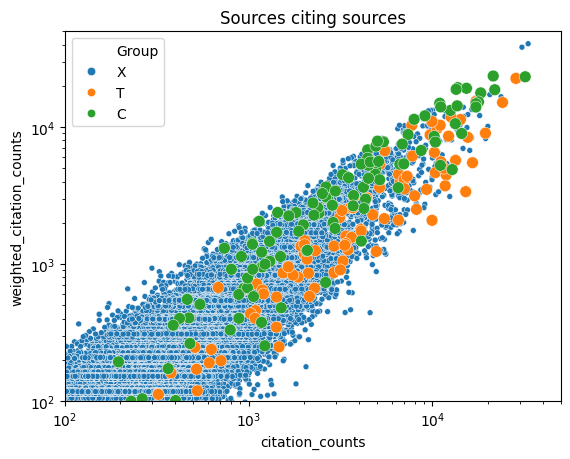

citer_kind = 'source' cited_kind = 'institution'
*** DROP EDGES WITH FEWER THAN 50 CITATIONS df_edges.shape = (86821, 3)
                               citer                             cited  weights
32    https://openalex.org/S62142384  https://openalex.org/I4210144674       65
33    https://openalex.org/S62142384   https://openalex.org/I141810926      117
34    https://openalex.org/S62142384  https://openalex.org/I1310145890       99
50   https://openalex.org/S149339240   https://openalex.org/I909854389      194
170   https://openalex.org/S34139249    https://openalex.org/I87216513      131
[(0, 1), (0, 2), (0, 3), (4, 5), (6, 7), (6, 8), (6, 9), (10, 11), (10, 12), (13, 14), (13, 15), (16, 17), (16, 18), (16, 19), (16, 20), (16, 21), (0, 22), (0, 23), (0, 24), (0, 25), (0, 26), (0, 15), (0, 27), (28, 29), (28, 30), (28, 31), (4, 32), (33, 34), (35, 36), (37, 38), (10, 39), (10, 40), (10, 41), (10, 42), (10, 43), (10, 44), (10, 36), (10, 45), (10, 46), (10, 47), (10, 48), (10, 49), 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────┬──────────────────────────┬──────────────────────────────────┬─────────────────────────────┐
│ citation_counts │ weighted_citation_counts │             cited_id             │         cited_name          │
│      int64      │          double          │             varchar              │           varchar           │
├─────────────────┼──────────────────────────┼──────────────────────────────────┼─────────────────────────────┤
│              16 │        4.117876455409653 │ https://openalex.org/A5001632395 │ Susann Thiel                │
│              16 │        7.896149496399793 │ https://openalex.org/A5046528065 │ Gary R. Watmough            │
│              16 │       3.9612281218543184 │ https://openalex.org/A5071528122 │ Sergi Sauri Marchan         │
│              16 │        3.043175449294773 │ https://openalex.org/A5066308038 │ Mohamed Badaoui             │
│              16 │       11.093683421135896 │ https://openalex.org/A5112618691 │ Fang-Yu Yeh           

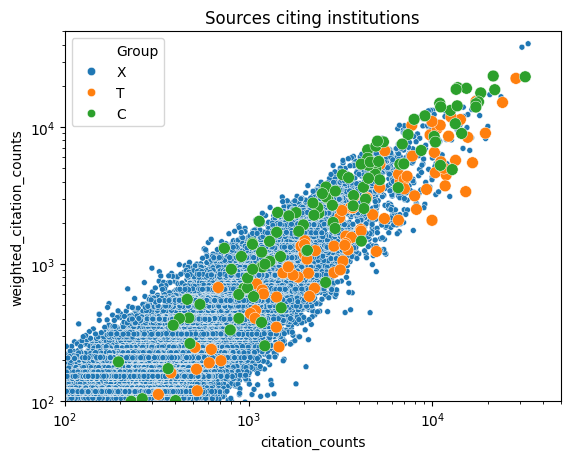

citer_kind = 'institution' cited_kind = 'source'
*** DROP EDGES WITH FEWER THAN 50 CITATIONS df_edges.shape = (88164, 3)
                                citer                            cited  weights
163     https://openalex.org/I8833935  https://openalex.org/S159637997      141
205   https://openalex.org/I200769079  https://openalex.org/S186558940      306
208  https://openalex.org/I3018083178  https://openalex.org/S173966628       70
212   https://openalex.org/I201841394  https://openalex.org/S159637997       73
221  https://openalex.org/I4210166174  https://openalex.org/S180723199      101
[(0, 1), (2, 3), (4, 5), (6, 1), (7, 8), (9, 10), (11, 12), (13, 14), (15, 1), (16, 17), (18, 19), (20, 21), (0, 22), (23, 24), (25, 5), (26, 27), (28, 5), (29, 30), (31, 32), (33, 34), (35, 36), (37, 38), (39, 40), (15, 41), (42, 21), (43, 22), (44, 22), (45, 22), (46, 22), (47, 5), (48, 5), (49, 3), (50, 24), (51, 52), (53, 54), (55, 56), (57, 58), (59, 60), (61, 62), (63, 64), (65, 66), (67, 6

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────┬──────────────────────────┬──────────────────────────────────┬─────────────────────────┐
│ citation_counts │ weighted_citation_counts │             cited_id             │       cited_name        │
│      int64      │          double          │             varchar              │         varchar         │
├─────────────────┼──────────────────────────┼──────────────────────────────────┼─────────────────────────┤
│           30299 │       10124.978525876824 │ https://openalex.org/A5051751338 │ Ulrike Malmendier       │
│           28452 │        7505.613454274104 │ https://openalex.org/A5012301204 │ Daron Acemoglu          │
│           27918 │        9421.734207537424 │ https://openalex.org/A5088371729 │ Stefan Nagel            │
│           25695 │         8366.66347018937 │ https://openalex.org/A5029839974 │ David Autor             │
│           21592 │         4058.48763230855 │ https://openalex.org/A5084716352 │ Armin Falk              │
│           21266 │       11

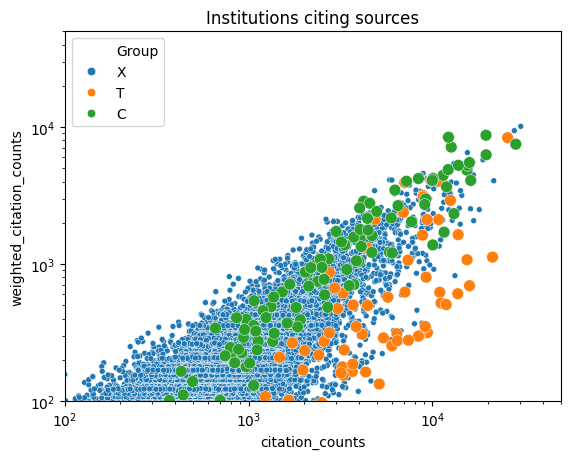

citer_kind = 'institution' cited_kind = 'institution'
*** DROP EDGES WITH FEWER THAN 50 CITATIONS df_edges.shape = (70141, 3)
                              citer                             cited  weights
0  https://openalex.org/I4403928399    https://openalex.org/I50357001       59
1  https://openalex.org/I4403928399    https://openalex.org/I63966007       91
2   https://openalex.org/I185261750   https://openalex.org/I141945490      481
5    https://openalex.org/I57995698  https://openalex.org/I4210126650       65
9   https://openalex.org/I181565077   https://openalex.org/I181565077     1807
[(0, 1), (0, 2), (3, 4), (5, 6), (7, 7), (7, 8), (9, 10), (11, 2), (12, 13), (14, 15), (16, 17), (18, 19), (20, 21), (22, 23), (15, 24), (25, 26), (27, 28), (29, 30), (31, 3), (32, 33), (34, 35), (36, 37), (38, 39), (40, 41), (42, 43), (44, 45), (46, 35), (47, 48), (49, 50), (51, 13), (52, 53), (54, 15), (55, 55), (56, 57), (58, 10), (59, 21), (60, 2), (61, 30), (61, 62), (63, 23), (64, 2), (65, 3

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────┬──────────────────────────┬──────────────────────────────────┬─────────────────────┐
│ citation_counts │ weighted_citation_counts │             cited_id             │     cited_name      │
│      int64      │          double          │             varchar              │       varchar       │
├─────────────────┼──────────────────────────┼──────────────────────────────────┼─────────────────────┤
│           30299 │       10124.978525876682 │ https://openalex.org/A5051751338 │ Ulrike Malmendier   │
│           28452 │        7505.613454274107 │ https://openalex.org/A5012301204 │ Daron Acemoglu      │
│           27918 │        9421.734207537269 │ https://openalex.org/A5088371729 │ Stefan Nagel        │
│           25695 │        8366.663470189367 │ https://openalex.org/A5029839974 │ David Autor         │
│           21592 │        4058.487632308558 │ https://openalex.org/A5084716352 │ Armin Falk          │
│           21266 │       1123.6589122488883 │ https://openalex.

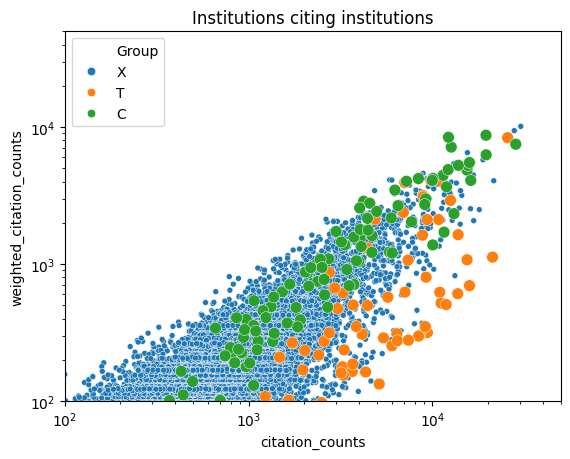

DONE!


In [88]:
if __name__ == "__main__":
    main()
    print("DONE!")